In [4]:
def train_and_compare_models(
    X_train,
    X_test,
    y_train,
    y_test
):

    print("DEBUG X_train type:", type(X_train))
    print("DEBUG X_train shape:", X_train.shape)

    print("DEBUG X_test type:", type(X_test))
    print("DEBUG X_test shape:", X_test.shape)

    models = create_models()

    results = []

    best_model = None

    best_f1 = -1

    best_model_name = None

    for model_name, classifier in models.items():

        print(
            f"\nTraining {model_name}..."
        )

        preprocessor = create_preprocessor()

        pipeline = Pipeline(

            steps=[

                (
                    "preprocessor",

                    preprocessor
                ),

                (
                    "classifier",

                    classifier
                )
            ]
        )

        # Train model
        pipeline.fit(

            X_train,

            y_train
        )

        # Predictions
        predictions = pipeline.predict(

            X_test
        )

        # Metrics
        accuracy = accuracy_score(

            y_test,

            predictions
        )

        precision = precision_score(

            y_test,

            predictions,

            zero_division=0
        )

        recall = recall_score(

            y_test,

            predictions,

            zero_division=0
        )

        f1 = f1_score(

            y_test,

            predictions,

            zero_division=0
        )

        # Store results
        results.append(

            {

                "Model": model_name,

                "Accuracy": accuracy,

                "Precision": precision,

                "Recall": recall,

                "F1_Score": f1
            }
        )

        print(
            f"{model_name} completed."
        )

        print(
            f"Accuracy: {accuracy:.4f}"
        )

        print(
            f"Precision: {precision:.4f}"
        )

        print(
            f"Recall: {recall:.4f}"
        )

        print(
            f"F1 Score: {f1:.4f}"
        )

        # Select best model
        if f1 > best_f1:

            best_f1 = f1

            best_model = pipeline

            best_model_name = model_name

    # Convert results into DataFrame
    results_df = pd.DataFrame(

        results
    )

    print("\nMODEL COMPARISON")

    print(
        results_df
    )

    print(
        f"\nBest Model: {best_model_name}"
    )

    # VERY IMPORTANT
    return (

        results_df,

        best_model,

        best_model_name
    )

In [5]:
import sys

if "src.model_training" in sys.modules:
    del sys.modules["src.model_training"]

In [6]:
import sys

sys.path.insert(
    0,
    r"D:\fake job posting detection"
)

from src.model_training import train_and_compare_models

In [7]:
import os
import sys

import pandas as pd

from sklearn.model_selection import train_test_split


from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline

PROJECT_ROOT = os.path.dirname(
    os.getcwd()
)

sys.path.append(
    PROJECT_ROOT
)

In [8]:
from src.model_training import (

    load_processed_data,

    prepare_data,

    train_and_compare_models
)

In [9]:
df = pd.read_csv(
    "D:/fake job posting detection/data/fake_job_posting.csv"
)

In [10]:
data_path = os.path.join(

    PROJECT_ROOT,

    "data",

    "D:/fake job posting detection/data/fake_job_posting.csv"
)

df = load_processed_data(
    data_path
)

df.head()

,Job_id,Title,Location,Department,Salary_range,Company_profile,Description,Requirements,Benefits,Telecommuting,Has_company_logo,Has_questions,Employment_type,Required_experience,Required_education,Industry,Function,Fraudulent,combined_text
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0,NaN
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0,NaN
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0,NaN
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,NaN
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,NaN


In [11]:
df = load_processed_data(
    data_path
)

print(df.shape)
print(df.columns.tolist())

(17880, 19)
['Job_id', 'Title', 'Location', 'Department', 'Salary_range', 'Company_profile', 'Description', 'Requirements', 'Benefits', 'Telecommuting', 'Has_company_logo', 'Has_questions', 'Employment_type', 'Required_experience', 'Required_education', 'Industry', 'Function', 'Fraudulent', 'combined_text']


In [12]:
X, y = prepare_data(
    df
)

In [13]:
print(type(X))
print(X.shape)

print(type(y))
print(y.shape)

<class 'pandas.core.frame.DataFrame'>
(17880, 9)
<class 'pandas.core.series.Series'>
(17880,)


In [14]:
X = df["combined_text"]

y = df["Fraudulent"]

In [15]:
print(X.shape)

print(y.shape)

(17880,)
(17880,)


In [16]:
X = X.fillna("")

In [17]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [18]:
print(type(X_train))
print(X_train.shape)

print(type(X_test))
print(X_test.shape)

print(X_train.head())

<class 'pandas.core.series.Series'>
(14304,)
<class 'pandas.core.series.Series'>
(3576,)
7530     
129      
4640     
402      
13218    
Name: combined_text, dtype: object


In [19]:
# Select all required input columns
feature_columns = [
    "combined_text",
    "Telecommuting",
    "Has_company_logo",
    "Has_questions",
    "Employment_type",
    "Required_experience",
    "Required_education",
    "Industry",
    "Function"
]

# Create X as a DataFrame
X = df[feature_columns].copy()

# Create y as a Series
y = df["Fraudulent"].copy()

# Handle missing values
X["combined_text"] = (
    X["combined_text"]
    .fillna("")
    .astype(str)
)

# Numeric columns
numeric_columns = [
    "Telecommuting",
    "Has_company_logo",
    "Has_questions"
]

for column in numeric_columns:
    X[column] = pd.to_numeric(
        X[column],
        errors="coerce"
    )

    X[column] = X[column].fillna(0)


# Categorical columns
categorical_columns = [
    "Employment_type",
    "Required_experience",
    "Required_education",
    "Industry",
    "Function"
]

for column in categorical_columns:
    X[column] = (
        X[column]
        .fillna("Unknown")
        .astype(str)
    )


# Target variable
y = pd.to_numeric(
    y,
    errors="coerce"
)

# Remove rows where target is missing
valid_rows = y.notna()

X = X.loc[valid_rows].reset_index(drop=True)

y = y.loc[valid_rows].astype(int).reset_index(drop=True)


print("X shape:", X.shape)
print("y shape:", y.shape)
print("X type:", type(X))
print("y type:", type(y))
print(X.columns.tolist())

X shape: (17880, 9)
y shape: (17880,)
X type: <class 'pandas.core.frame.DataFrame'>
y type: <class 'pandas.core.series.Series'>
['combined_text', 'Telecommuting', 'Has_company_logo', 'Has_questions', 'Employment_type', 'Required_experience', 'Required_education', 'Industry', 'Function']


In [20]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (14304,)
X_test: (3576,)
y_train: (14304,)
y_test: (3576,)


In [22]:
text_columns = [
    "Title",
    "Company_profile",
    "Description",
    "Requirements",
    "Benefits"
]

for column in text_columns:
    df[column] = (
        df[column]
        .fillna("")
        .astype(str)
    )

df["combined_text"] = (
    df["Title"] + " " +
    df["Company_profile"] + " " +
    df["Description"] + " " +
    df["Requirements"] + " " +
    df["Benefits"]
)

In [23]:
print(df["combined_text"].head())
print(df["combined_text"].str.len().describe())

0    Marketing Intern We're Food52, and we've creat...
1    Customer Service - Cloud Video Production 90 S...
2    Commissioning Machinery Assistant (CMA) Valor ...
3    Account Executive - Washington DC Our passion ...
4    Bill Review Manager SpotSource Solutions LLC i...
Name: combined_text, dtype: object
count    17880.000000
mean      2670.372875
std       1465.556152
min         18.000000
25%       1595.000000
50%       2522.000000
75%       3475.000000
max      14945.000000
Name: combined_text, dtype: float64


In [24]:
feature_columns = [
    "combined_text",
    "Telecommuting",
    "Has_company_logo",
    "Has_questions",
    "Employment_type",
    "Required_experience",
    "Required_education",
    "Industry",
    "Function"
]

X = df[feature_columns].copy()

y = df["Fraudulent"].copy()

In [25]:
X["combined_text"] = (
    X["combined_text"]
    .fillna("")
    .astype(str)
)

In [26]:
categorical_columns = [
    "Employment_type",
    "Required_experience",
    "Required_education",
    "Industry",
    "Function"
]

for column in categorical_columns:
    X[column] = (
        X[column]
        .fillna("Unknown")
        .astype(str)
    )

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [28]:
results_df, best_model, best_model_name = train_and_compare_models(
    X_train,
    X_test,
    y_train,
    y_test
)

results_df


Training Logistic Regression...
Logistic Regression completed.
Accuracy: 0.9684
Precision: 0.6163
Recall: 0.9191
F1 Score: 0.7378

Training Naive Bayes...
Naive Bayes completed.
Accuracy: 0.9662
Precision: 0.7955
Recall: 0.4046
F1 Score: 0.5364

Training Linear SVM...
Linear SVM completed.
Accuracy: 0.9885
Precision: 0.8837
Recall: 0.8786
F1 Score: 0.8812


,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.968400,0.616279,0.919075,0.737819
1,Naive Bayes,0.966163,0.795455,0.404624,0.536398
2,Linear SVM,0.988535,0.883721,0.878613,0.881159


In [29]:
print(best_model_name)
print(best_model)

Linear SVM
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('tfidf',
                                                                   TfidfVectorizer(max_features=10000,
                                                                                   ngram_range=(1,
                                                                                                2),
                                                                                   stop_words='english',
                                                                                   sublinear_tf=True))]),
                                                  'combined_text'),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
       

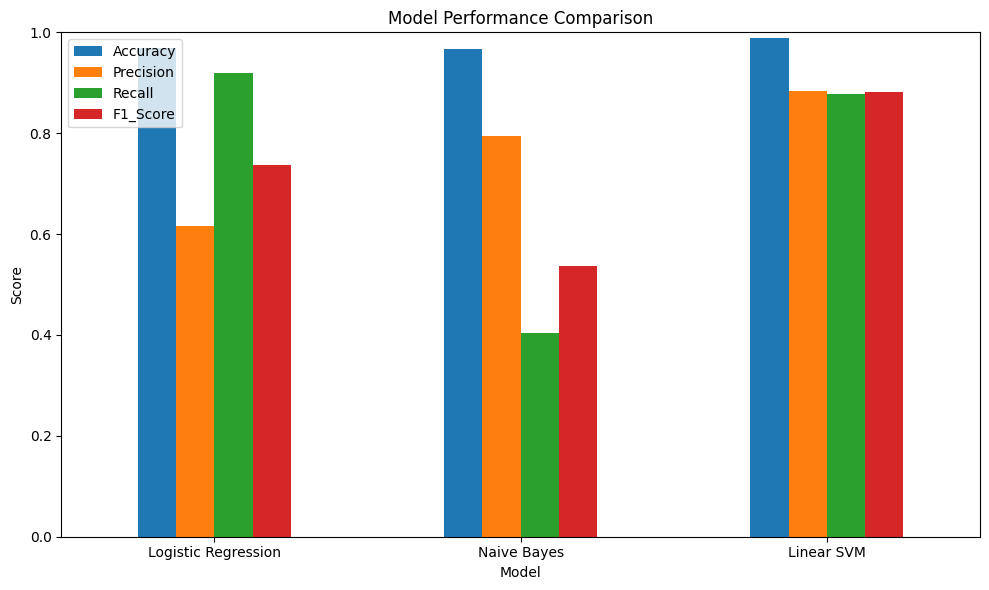

In [39]:
import matplotlib.pyplot as plt

results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1_Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.tight_layout()

plt.show()

In [30]:
import os
import joblib

PROJECT_PATH = r"D:\fake job posting detection"

MODELS_PATH = os.path.join(
    PROJECT_PATH,
    "models"
)

os.makedirs(
    MODELS_PATH,
    exist_ok=True
)

MODEL_PATH = os.path.join(
    MODELS_PATH,
    "model.pkl"
)

joblib.dump(
    best_model,
    MODEL_PATH
)

print("Model saved successfully!")
print("Path:", MODEL_PATH)
print("File exists:", os.path.exists(MODEL_PATH))
print("File size:", os.path.getsize(MODEL_PATH), "bytes")

Model saved successfully!
Path: D:\fake job posting detection\models\model.pkl
File exists: True
File size: 506438 bytes


In [31]:
loaded_model = joblib.load(
    MODEL_PATH
)

print("Model loaded successfully!")
print(loaded_model)

Model loaded successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('text',
                                                  Pipeline(steps=[('tfidf',
                                                                   TfidfVectorizer(max_features=10000,
                                                                                   ngram_range=(1,
                                                                                                2),
                                                                                   stop_words='english',
                                                                                   sublinear_tf=True))]),
                                                  'combined_text'),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_